<a href="https://colab.research.google.com/github/grasht/projects_ML_HW_6/blob/main/HW6_pt3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Compare Seed 3 and DDPM CIFAR10 32

In [ ]:
import torch
from diffusers import DDPMPipeline
import math
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# CIFAR-10 pretrained DDPM
pipe = DDPMPipeline.from_pretrained(
    "google/ddpm-cifar10-32",
    torch_dtype=torch.float32
).to(device)

model = pipe.unet
scheduler = pipe.scheduler

In [ ]:
from diffusers import DPMSolverMultistepScheduler

dpm_scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe.scheduler = dpm_scheduler


def sample_dpm(steps):
    return pipe(num_inference_steps=steps).images

# Implement Seed 3 like they do in the paper

**Note:** I was not successful in reproducing this. While the paper has a github, it does not make implementing SEED3 simple and does not provide steps for running their code. That part say its "to come".

In [ ]:
import torch

def beta_fn(t):
    # simple linear schedule
    return 0.1 + 0.9 * t


def seeds_step(x, t, dt, model):
    beta = beta_fn(t)

    #exponential drift
    exp_factor = math.exp(-0.5 * beta * dt)
    x = exp_factor * x

    #score prediction
    with torch.no_grad():
        score = model(x, t).sample

    #deterministic correction
    x = x - beta * dt * score

    #stochastic correction
    noise = torch.randn_like(x)
    x = x + math.sqrt(beta * dt) * noise

    return x

In [ ]:
def sample_seeds(model, steps):
    x = torch.randn(1, 3, 32, 32).to(device)

    for i in range(steps):
        t = i / steps
        dt = 1.0 / steps
        x = seeds_step(x, t, dt, model)

    # convert to image range
    x = (x.clamp(-1, 1) + 1) / 2
    return x

In [ ]:
import matplotlib.pyplot as plt

# DPM-Solver
dpm_images = sample_dpm(200)

# SEEDS
seeds_image = sample_seeds(model, 200)

# visualize
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.title("DPM-Solver")
plt.imshow(dpm_images[0])
plt.axis("off")

plt.subplot(1,2,2)
plt.title("SEEDS")
plt.imshow(seeds_image[0].permute(1,2,0).cpu())
plt.axis("off")

plt.show()

Not the expected results

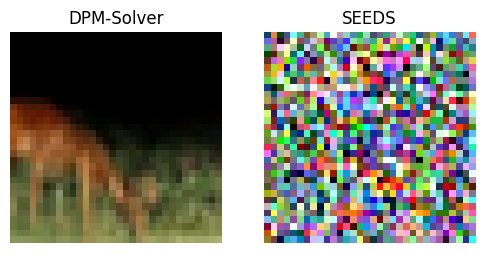

@todo: Graph the results